Project: Customer Churn Prediction
🎯 Problem

A telecom company wants to predict whether a customer will leave the company (churn).

0 → Customer stays
1 → Customer leaves

We'll use around 200 customers and deliberately include:

Multiple features
Different feature scales
Some noise
Overlapping classes
Features that aren't perfectly predictive



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 200

data = {
    "age": np.random.randint(18, 65, n),

    "tenure_months": np.random.randint(1, 73, n),

    "monthly_charges": np.round(
        np.random.uniform(20, 150, n), 2
    ),

    "total_charges": np.round(
        np.random.uniform(500, 10000, n), 2
    ),

    "support_calls": np.random.randint(0, 12, n),

    "data_usage_gb": np.round(
        np.random.uniform(1, 100, n), 2
    ),

    "contract_length": np.random.choice(
        [1, 12, 24, 36], n
    ),

    "payment_delay": np.random.randint(0, 10, n),

    "satisfaction_score": np.random.randint(1, 11, n),

    "referrals": np.random.randint(0, 8, n)
}

df = pd.DataFrame(data)

# Create churn using several factors + random noise
churn_score = (
    0.8 * df["support_calls"]
    + 0.7 * df["payment_delay"]
    - 0.08 * df["tenure_months"]
    - 0.5 * df["satisfaction_score"]
    - 0.03 * df["contract_length"]
    + np.random.normal(0, 3, n)
)

df["churn"] = (churn_score > 3).astype(int)

df

,age,tenure_months,monthly_charges,total_charges,support_calls,data_usage_gb,contract_length,payment_delay,satisfaction_score,referrals,churn
0,56,39,75.68,2065.93,0,97.58,1,7,9,1,0
1,46,2,109.50,4406.92,4,46.44,12,0,3,1,0
2,32,3,27.57,7887.22,11,56.17,1,5,10,4,1
3,60,56,138.98,5063.52,11,86.20,36,7,3,0,1
4,25,59,77.51,9860.22,1,53.97,1,2,7,6,0
...,...,...,...,...,...,...,...,...,...,...,...
195,49,19,95.55,525.75,11,41.04,12,8,6,6,1
196,49,58,139.49,1608.61,1,57.67,24,9,4,4,0
197,41,55,30.76,4995.08,4,80.59,36,1,6,0,0
198,58,62,133.97,6257.97,0,54.30,36,5,3,5,0


# Understand the data

In [2]:
df.shape

(200, 11)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 200 non-null    int64  
 1   tenure_months       200 non-null    int64  
 2   monthly_charges     200 non-null    float64
 3   total_charges       200 non-null    float64
 4   support_calls       200 non-null    int64  
 5   data_usage_gb       200 non-null    float64
 6   contract_length     200 non-null    int64  
 7   payment_delay       200 non-null    int64  
 8   satisfaction_score  200 non-null    int64  
 9   referrals           200 non-null    int64  
 10  churn               200 non-null    int64  
dtypes: float64(3), int64(8)
memory usage: 17.3 KB


In [4]:
df.isnull().sum()

age                   0
tenure_months         0
monthly_charges       0
total_charges         0
support_calls         0
data_usage_gb         0
contract_length       0
payment_delay         0
satisfaction_score    0
referrals             0
churn                 0
dtype: int64

In [5]:
df["churn"].value_counts()

churn
0    123
1     77
Name: count, dtype: int64

# Visualise the data

[]

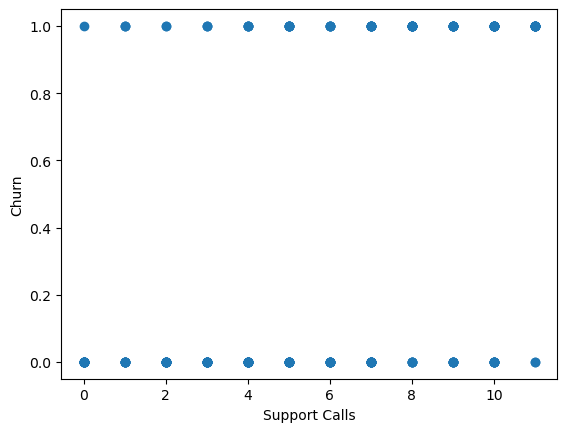

In [36]:
plt.scatter(df["support_calls"],df["churn"])
plt.xlabel("Support Calls")
plt.ylabel("Churn")
plt.plot()

# Separate the data

In [6]:
X = df[["age" , "tenure_months" , "monthly_charges" , "total_charges" , "support_calls" , "data_usage_gb" , "contract_length" , "payment_delay" , "satisfaction_score" , "referrals"]]
Y = df["churn"]

# Train and test split

In [7]:
from sklearn.model_selection import train_test_split
X_train , X_test , Y_train , Y_test = train_test_split(X , Y , test_size = 0.2 , random_state = 42 , stratify = Y)

# Create a decision tree model 

In [8]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion="gini" , random_state=42)

# Train the model

In [9]:
model.fit(X_train , Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# Test the model

In [10]:
pred = model.predict(X_test)
print("Actual",Y_test)
print("Prediction",pred)

Actual 1      0
170    0
120    1
141    0
65     1
81     0
98     1
117    0
183    1
93     1
92     0
15     1
142    0
158    1
104    1
174    0
113    0
180    0
77     1
182    0
35     0
111    1
171    0
36     0
134    0
184    1
164    0
40     0
187    0
4      0
198    0
59     1
24     1
110    1
58     0
151    0
26     0
126    1
80     0
47     0
Name: churn, dtype: int64
Prediction [0 0 1 0 0 0 1 0 1 1 0 1 0 1 0 0 0 1 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0
 0 1 0]


# Evaluate the result

In [12]:
# Accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_test , pred)
print(accuracy)

0.725


In [13]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(Y_test , pred)
print(confusion)

[[21  4]
 [ 7  8]]


In [14]:
# Precision
from sklearn.metrics import precision_score
precision = precision_score(Y_test , pred)
print(precision)

0.6666666666666666


In [15]:
# Recall
from sklearn.metrics import recall_score
recall = recall_score(Y_test , pred)
print(recall)

0.5333333333333333


In [16]:
# F1 score
from sklearn.metrics import f1_score
f1 = f1_score(Y_test , pred)
print(f1)

0.5925925925925926


In [19]:
# Classification Report
from sklearn.metrics import classification_report
classi = classification_report(Y_test , pred)
print(classi)

              precision    recall  f1-score   support

           0       0.75      0.84      0.79        25
           1       0.67      0.53      0.59        15

    accuracy                           0.72        40
   macro avg       0.71      0.69      0.69        40
weighted avg       0.72      0.72      0.72        40



# Visualise the data

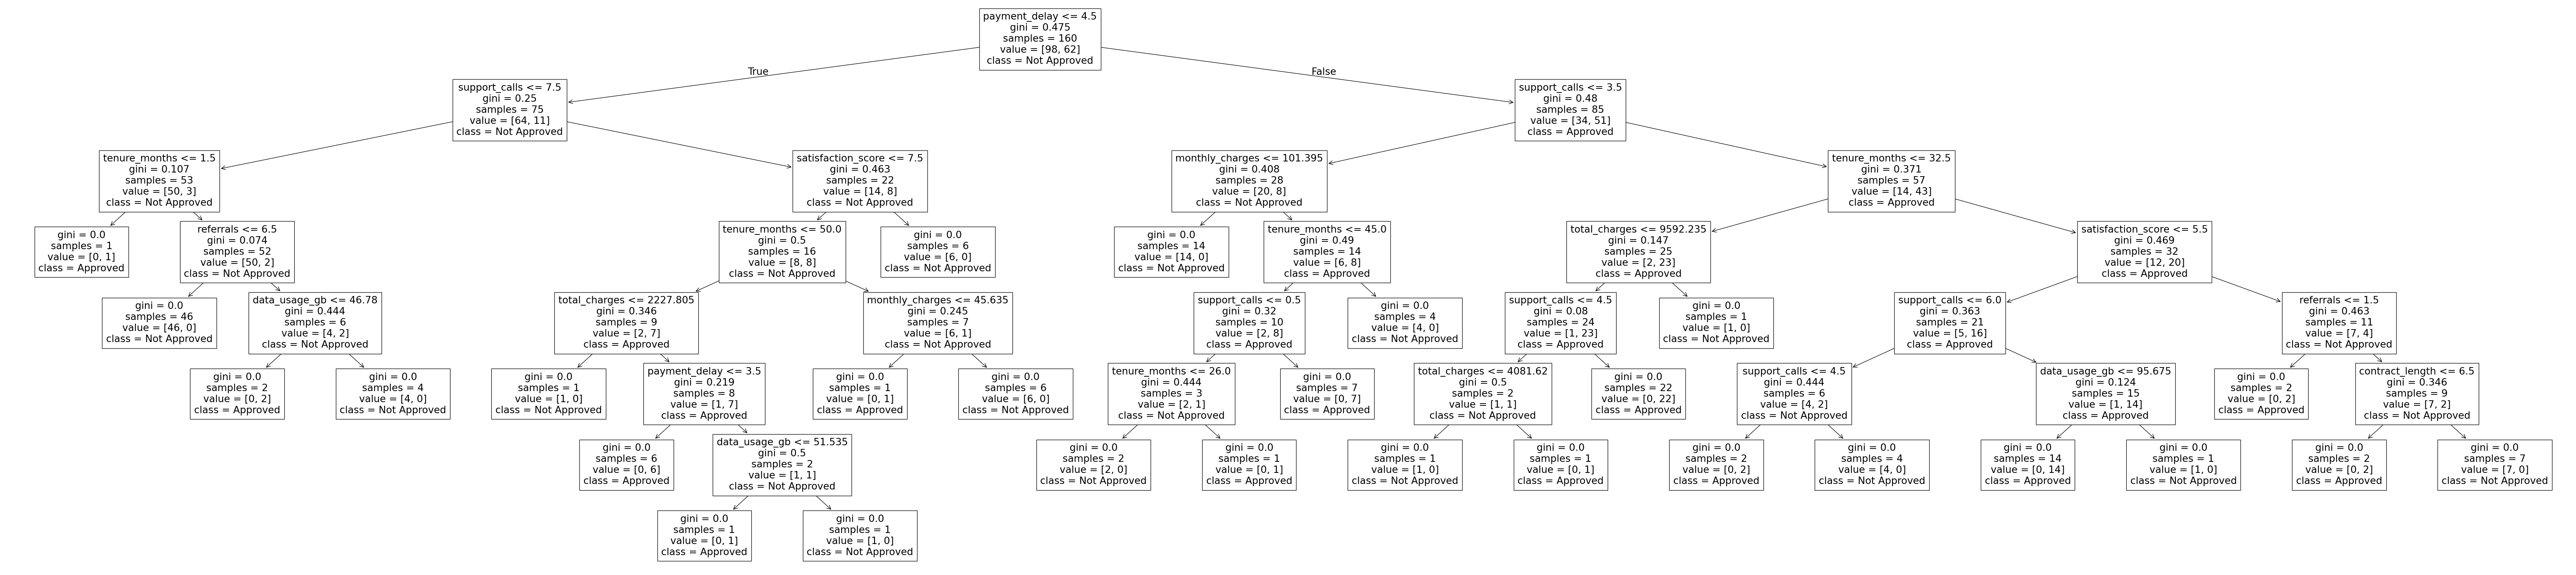

In [29]:
from sklearn.tree import plot_tree
plt.figure(figsize=(90,20))
plot_tree(
    model , 
    feature_names = X.columns ,
    class_names = ["Not Approved" , "Approved"]
)
plt.show()

# Feature Importance

In [35]:
importance = pd.Series(
    model.feature_importances_ , 
    index = X.columns
)
print(importance.sort_values(ascending = False))

support_calls         0.259585
payment_delay         0.225499
tenure_months         0.163556
monthly_charges       0.082761
data_usage_gb         0.072855
satisfaction_score    0.058879
total_charges         0.054305
referrals             0.041597
contract_length       0.040963
age                   0.000000
dtype: float64


In [39]:
# Max depth
print("Depth :" , model.get_depth())
# No of branches
print("Branchs :" , model.get_n_leaves())

Depth : 7
Branchs : 27


# Control Overfitting

In [42]:
train_score = []
test_score = []
depth = [1,2,3,4,5,6,7,8]
for i in depth:
    model = DecisionTreeClassifier(criterion="gini",random_state=42,max_depth=i)
    model.fit(X_train , Y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_score.append(accuracy_score(Y_train , train_pred))
    test_score.append(accuracy_score(Y_test , test_pred))
print(train_score)
print(test_score)

[0.71875, 0.79375, 0.8125, 0.89375, 0.95, 0.99375, 1.0, 1.0]
[0.575, 0.675, 0.625, 0.7, 0.725, 0.725, 0.725, 0.725]


# Create a new model

In [100]:
from sklearn.tree import DecisionTreeClassifier
final_model = DecisionTreeClassifier(criterion="gini" , random_state=42 , max_depth = 6 ,min_samples_split=4)

# Train the model

In [101]:
final_model.fit(X_train , Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,4
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# Test the data model

In [102]:
final_pred = model.predict(X_test)
print("Actual",Y_train)
print("Prediction",final_pred)

Actual 85     0
136    1
89     1
169    0
50     0
      ..
177    1
188    0
52     1
67     0
155    1
Name: churn, Length: 160, dtype: int64
Prediction [0 0 1 0 0 0 1 0 1 1 0 1 0 1 0 0 0 1 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0
 0 1 0]


# Evaluate the new data

In [103]:
print("Accuracy:",accuracy_score(Y_test, final_pred))
print("Confusion Matrix:",confusion_matrix(Y_test, final_pred))
print("Precision:",precision_score(Y_test, final_pred))
print("Recall:",recall_score(Y_test, final_pred))
print("F1 Score:",f1_score(Y_test, final_pred))

Accuracy: 0.725
Confusion Matrix: [[21  4]
 [ 7  8]]
Precision: 0.6666666666666666
Recall: 0.5333333333333333
F1 Score: 0.5925925925925926


# Visualise the data tree

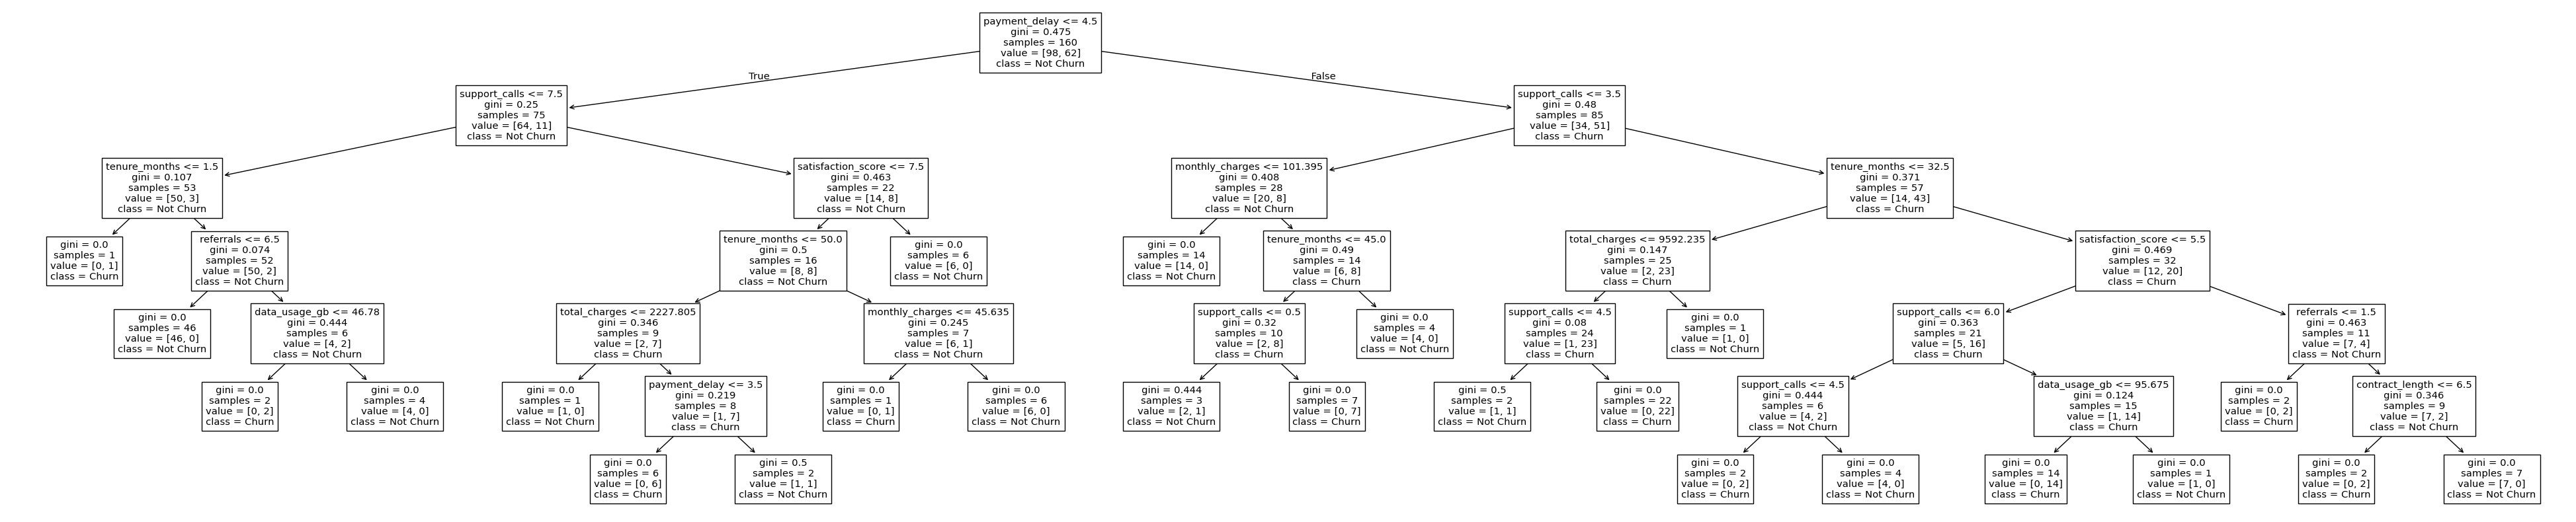

In [104]:
plt.figure(figsize=(50, 10))

plot_tree(
    final_model,
    feature_names=X.columns,
    class_names=["Not Churn", "Churn"]
)

plt.show()